In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
master_df = pd.read_csv('Team_Stats_Merge_2018_2025.csv')

In [3]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Columns: 103 entries, season to made_playoffs
dtypes: float64(63), int64(39), str(1)
memory usage: 206.1 KB


In [4]:
corr_matrix = master_df.corr(numeric_only=True)

In [5]:


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column].abs() > 0.85)
]

print(high_corr)

['tp_L', 'tp_W-L%', 'tp_PD', 'tp_MoV', 'tp_SRS', 'tp_OSRS', 'tp_DSRS', 'off_pts', 'off_yds', 'off_yds_per_play', 'off_penalty_yds', 'off_score_pct', 'off_turnover_pct', 'off_exp', 'def_g', 'def_pa', 'def_yds_per_play', 'def_score_pct', 'def_turnover_pct', 'def_exp', 'off_pass_G', 'off_pass_Att', 'off_pass_TD%', 'off_pass_Int', 'off_pass_Int%', 'off_pass_Y/A', 'off_pass_AY/A', 'off_pass_Y/G', 'off_pass_Rate', 'off_pass_Yds.1', 'off_pass_Sk%', 'off_pass_NY/A', 'off_pass_ANY/A', 'off_pass_EXP', 'off_rush_G', 'off_rush_Yds', 'off_rush_Y/G', 'def_pass_G', 'def_pass_Att', 'def_pass_TD%', 'def_pass_Int', 'def_pass_Int%', 'def_pass_Y/A', 'def_pass_AY/A', 'def_pass_Y/G', 'def_pass_Rate', 'def_pass_Yds.1', 'def_pass_Sk%', 'def_pass_NY/A', 'def_pass_ANY/A', 'def_pass_EXP', 'def_rush_G', 'def_rush_Y/G']


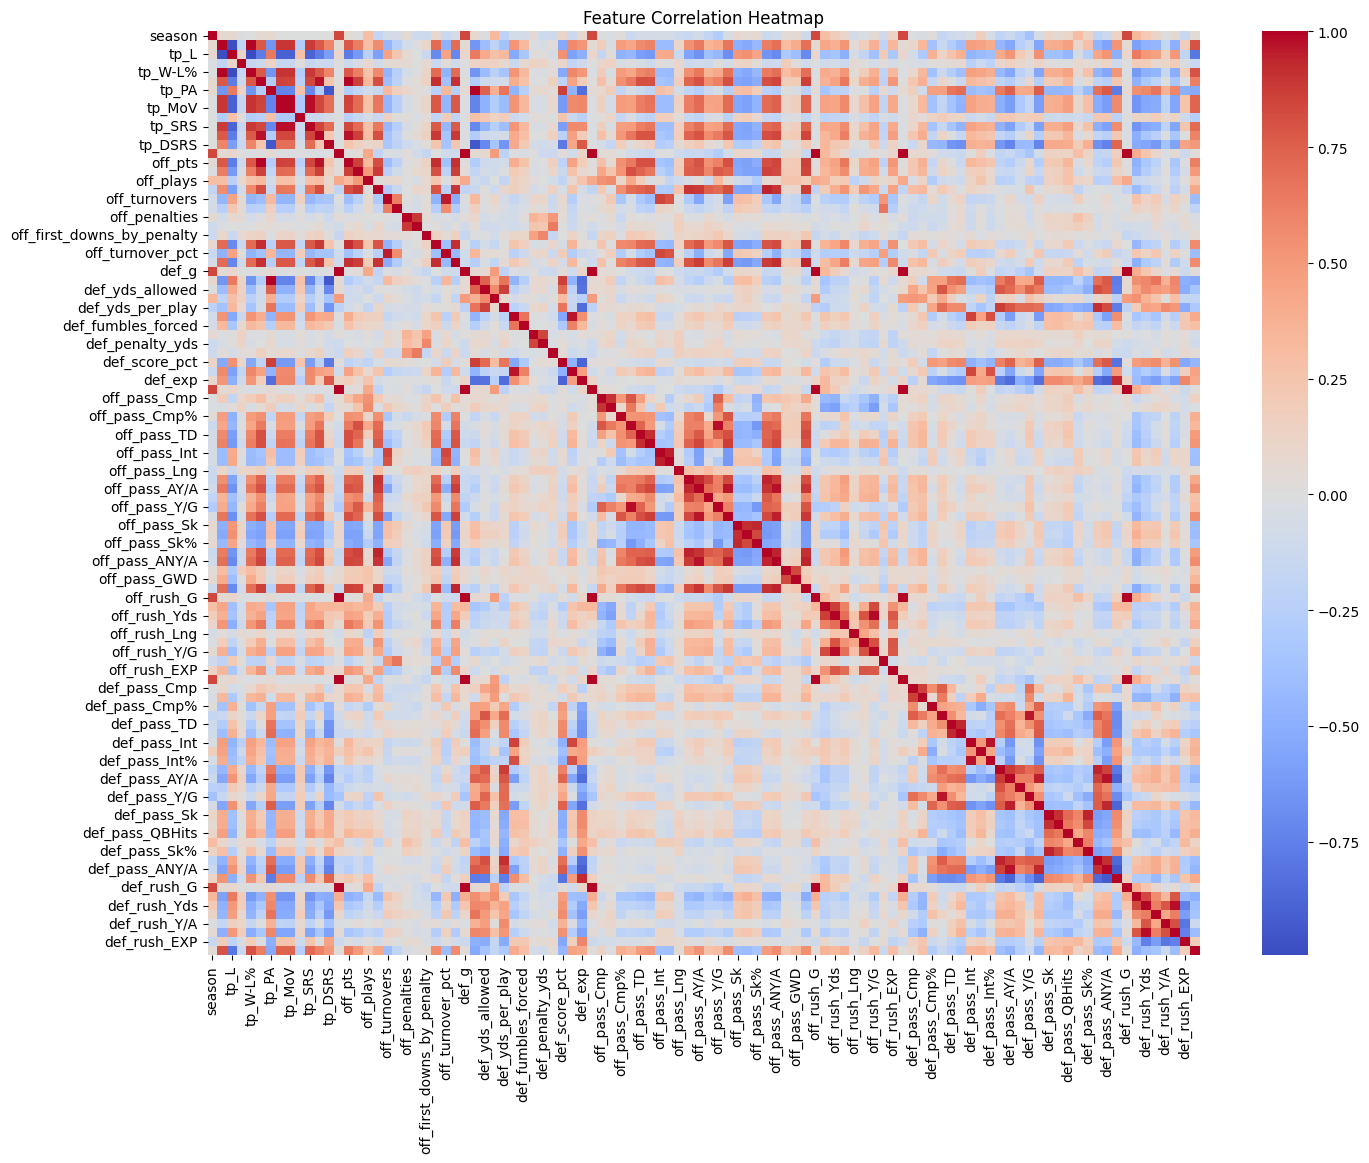

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))
sns.heatmap(master_df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# start with predictors only
X = master_df.drop(columns=["made_playoffs"], errors="ignore")

# explicitly drop non-model identifier columns if present
X = X.drop(columns=["team", "season"], errors="ignore")

# keep only numeric columns
X = X.select_dtypes(include=[np.number]).copy()

# replace inf values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# drop rows with missing values for VIF calculation
X = X.dropna()

# force everything to float
X = X.astype(float)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif.sort_values("VIF", ascending=False)
print(vif)

/Users/dylandellavalle/Documents/MDS/Capstone/nfl-decision-support-analytics/.conda/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


            Feature        VIF
0              tp_W        inf
77     def_pass_Int        inf
27  def_yds_allowed        inf
28        def_plays        inf
74     def_pass_Yds        inf
..              ...        ...
99     def_rush_EXP  71.077015
68     off_rush_Fmb  57.783320
65     off_rush_Lng  40.390483
59     off_pass_GWD  37.821115
58     off_pass_4QC  30.211510

[100 rows x 2 columns]


In [13]:
for col in master_df.columns:
    print(col)

season
team
tp_W
tp_L
tp_T
tp_W-L%
tp_PF
tp_PA
tp_PD
tp_MoV
tp_SoS
tp_SRS
tp_OSRS
tp_DSRS
off_g
off_pts
off_yds
off_plays
off_yds_per_play
off_turnovers
off_fumbles
off_penalties
off_penalty_yds
off_first_downs_by_penalty
off_score_pct
off_turnover_pct
off_exp
def_g
def_pa
def_yds_allowed
def_plays
def_yds_per_play
def_turnovers_forced
def_fumbles_forced
def_penalties
def_penalty_yds
def_first_downs_by_penalty
def_score_pct
def_turnover_pct
def_exp
off_pass_G
off_pass_Cmp
off_pass_Att
off_pass_Cmp%
off_pass_Yds
off_pass_TD
off_pass_TD%
off_pass_Int
off_pass_Int%
off_pass_Lng
off_pass_Y/A
off_pass_AY/A
off_pass_Y/C
off_pass_Y/G
off_pass_Rate
off_pass_Sk
off_pass_Yds.1
off_pass_Sk%
off_pass_NY/A
off_pass_ANY/A
off_pass_4QC
off_pass_GWD
off_pass_EXP
off_rush_G
off_rush_Att
off_rush_Yds
off_rush_TD
off_rush_Lng
off_rush_Y/A
off_rush_Y/G
off_rush_Fmb
off_rush_EXP
def_pass_G
def_pass_Cmp
def_pass_Att
def_pass_Cmp%
def_pass_Yds
def_pass_TD
def_pass_TD%
def_pass_Int
def_pass_PD
def_pass_Int%
d

In [24]:

features = [
'tp_SRS','tp_PD',
'off_yds_per_play','off_score_pct','off_turnover_pct','off_exp',
'off_pass_ANY/A','off_pass_TD%','off_pass_Int%',
'off_rush_Y/G','off_rush_EXP',
'def_yds_per_play','def_score_pct','def_turnover_pct','def_exp',
'def_pass_ANY/A','def_pass_Sk%','def_rush_Y/G',
'off_penalty_yds','def_penalty_yds'
]

X = master_df[features]
y = master_df["made_playoffs"]

In [28]:
model_df = pd.concat(
    [
        master_df[["season","team"]],  # identifiers
        X,
        y
    ],
    axis=1
)

model_df

,season,team,tp_SRS,tp_PD,off_yds_per_play,off_score_pct,off_turnover_pct,off_exp,off_pass_ANY/A,off_pass_TD%,...,def_yds_per_play,def_score_pct,def_turnover_pct,def_exp,def_pass_ANY/A,def_pass_Sk%,def_rush_Y/G,off_penalty_yds,def_penalty_yds,made_playoffs
0,2018,New England Patriots,5.2,111,5.9,40.8,9.2,147.66,7.3,5.1,...,5.7,32.6,15.0,-17.25,5.8,4.7,112.7,744,838,1
1,2018,Miami Dolphins,-8.8,-114,5.3,28.3,12.5,-44.43,5.6,5.7,...,6.1,39.9,14.2,-127.44,6.7,5.8,145.3,978,856,0
2,2018,Buffalo Bills,-6.9,-105,4.7,26.4,15.5,-96.90,3.7,2.6,...,4.9,33.3,14.3,16.95,4.9,6.8,114.9,992,976,0
3,2018,New York Jets,-7.8,-108,4.9,32.0,14.7,-97.61,4.8,3.4,...,5.7,39.1,9.9,-70.75,6.5,6.3,126.3,948,817,0
4,2018,Baltimore Ravens,7.0,102,5.3,40.7,10.7,81.02,6.0,3.2,...,4.8,29.1,9.5,30.09,5.2,6.9,82.9,940,1017,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,2025,New Orleans Saints,-4.9,-77,5.0,33.0,13.1,-19.68,5.6,3.2,...,4.8,40.2,11.2,4.59,5.8,8.4,120.6,920,913,0
252,2025,Seattle Seahawks,12.8,191,5.9,45.9,14.2,80.50,7.3,5.2,...,4.6,28.7,12.8,81.09,4.5,7.3,91.9,793,902,1
253,2025,Los Angeles Rams,12.5,172,6.2,47.0,8.3,219.88,8.2,7.7,...,5.2,34.3,14.9,6.16,5.5,7.4,110.8,573,922,1
254,2025,San Francisco 49ers,6.0,66,5.5,47.6,12.9,131.06,6.8,5.7,...,5.6,38.6,8.4,-115.46,7.1,3.3,107.8,651,734,1


In [29]:
model_df.to_csv("team_stats_model_ready.csv", index=False)